**Import Libraries**

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, roc_auc_score, RocCurveDisplay,
                             precision_recall_curve, average_precision_score,
                             make_scorer, fbeta_score
                             )
import seaborn as sns
import matplotlib.ticker as mtick
import plotly.express as ex
import tensorflow as tf
from tensorflow import keras
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import BaseEstimator, TransformerMixin  
from sklearn.inspection import permutation_importance

%matplotlib inline 
background_color = "#f6f6f6"

**Load Dataset**

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1115,809,Male,13.0,0,0,No,children,Urban,71.73,NaN,Unknown,0
2815,50215,Male,42.0,0,0,No,Govt_job,Rural,59.83,52.8,never smoked,0
3718,39632,Female,53.0,0,0,Yes,Private,Urban,209.50,41.8,never smoked,0
724,60983,Male,70.0,0,0,Yes,Private,Urban,64.41,29.4,smokes,0
3261,6011,Male,9.0,0,0,No,children,Urban,78.24,15.3,Unknown,0


**Check Dataset Size**

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5110
Number of columns: 12


**Display Columns and it data type**

In [4]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

**Explore data type with object have what atribute inside**

In [5]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')

gender : ['Male' 'Female' 'Other']
ever_married : ['Yes' 'No']
work_type : ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type : ['Urban' 'Rural']
smoking_status : ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


we would like to clean up the Other column , let see how many column contain gender == other

In [6]:
other_rows = df[df['gender'] == 'Other']
print("Rows containing 'Other':")
print(other_rows)

Rows containing 'Other':
         id gender   age  hypertension  heart_disease ever_married work_type  \
3116  56156  Other  26.0             0              0           No   Private   

     Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
3116          Rural             143.33  22.4  formerly smoked       0  


Well ,only 1 , so we will drop it

In [7]:
df.drop(df[df['gender'] == 'Other'].index, inplace=True)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5109
Number of columns: 12


**Check missing value**

In [8]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

**BMI Imputer as a Pipeline Step (fit on training data only, inside the pipeline)**


In [9]:
class BMIDecisionTreeImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = X.copy()

        bmi_features = X[['age', 'gender']]
        bmi_target = X['bmi']

        # Only use rows with known BMI
        mask = bmi_target.notna()

        self.bmi_model = Pipeline([
            ('scale', StandardScaler()),
            ('tree', DecisionTreeRegressor(random_state=42))
        ])

        self.bmi_model.fit(
            bmi_features.loc[mask],
            bmi_target.loc[mask]
        )

        return self

    def transform(self, X):
        X = X.copy()

        missing_mask = X['bmi'].isna()

        if missing_mask.any():
            predicted_bmi = self.bmi_model.predict(
                X.loc[missing_mask, ['age', 'gender']]
            )
            X.loc[missing_mask, 'bmi'] = predicted_bmi

        return X


In [10]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

**Check Duplicate Data**

In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


# Explore Data Analysis

In [12]:
fig = ex.pie(df, names='stroke', color_discrete_sequence=['#17BECF', '#FFC20A'])
fig.update_layout(title='<b>Proportion Of Stroke Samples<b>')
fig.show()


we can cearly see the dataset is unbalanced , so we will oversampling it using SMOTE approach in the futere

**Age Distribution**

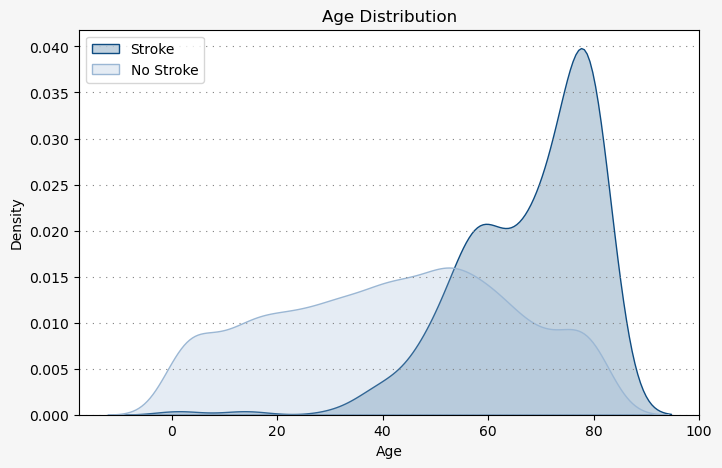

In [13]:
str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

ax.grid(color='gray', linestyle=':', axis='y', dashes=(1,5))

positive = pd.DataFrame(str_only["age"])
negative = pd.DataFrame(no_str_only["age"])

sns.kdeplot(positive["age"], ax=ax, color="#0f4c81", fill=True, label="Stroke")
sns.kdeplot(negative["age"], ax=ax, color="#9bb7d4", fill=True, label="No Stroke")

ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()

plt.show()

**Smoking Status**

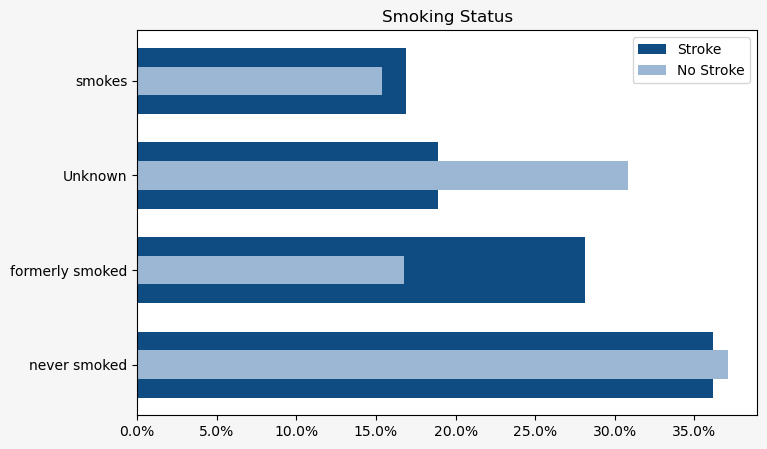

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["smoking_status"].value_counts())
positive["Percentage"] = (positive["count"] / positive["count"].sum()) * 100

negative = pd.DataFrame(no_str_only["smoking_status"].value_counts())
negative["Percentage"] = (negative["count"] / negative["count"].sum()) * 100

ax.barh(positive.index, positive["Percentage"], color="#0f4c81", height=0.7, label="Stroke")
ax.barh(negative.index, negative["Percentage"], color="#9bb7d4", height=0.3, label="No Stroke")

ax.set_title("Smoking Status")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

plt.show()

**Gender**

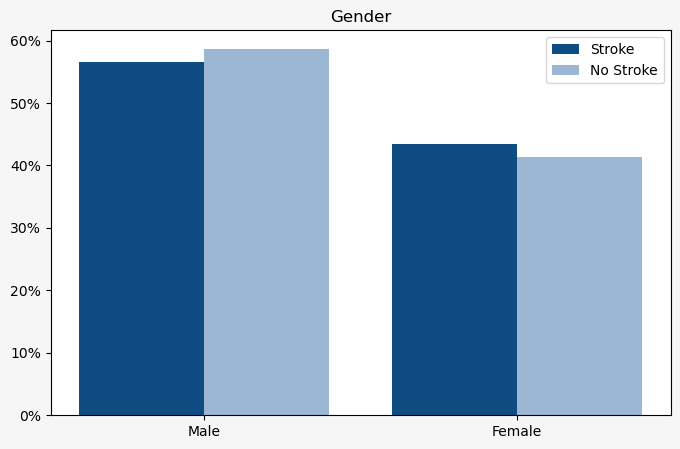

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["gender"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["gender"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["Male","Female"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Gender")
ax.legend()

plt.show()

**Heart Disease**

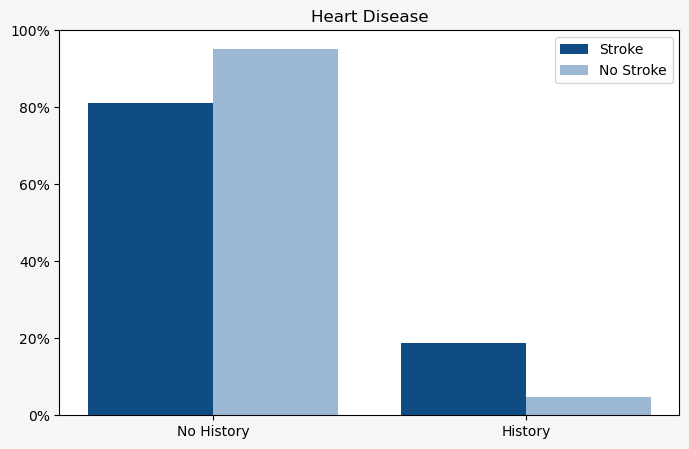

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["heart_disease"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["heart_disease"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Heart Disease")
ax.legend()

plt.show()

**Average Glucose Level**

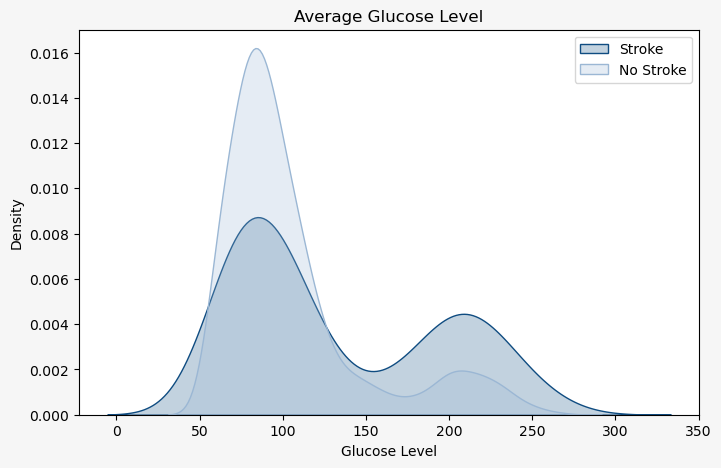

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["avg_glucose_level"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["avg_glucose_level"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("Average Glucose Level")
ax.set_xlabel("Glucose Level")
ax.legend()

plt.show()

**BMI**

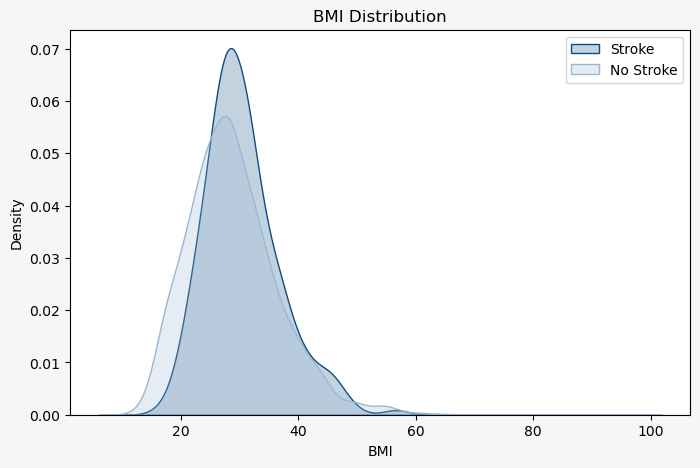

In [18]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["bmi"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["bmi"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("BMI Distribution")
ax.set_xlabel("BMI")
ax.legend()

plt.show()

**Work Type**

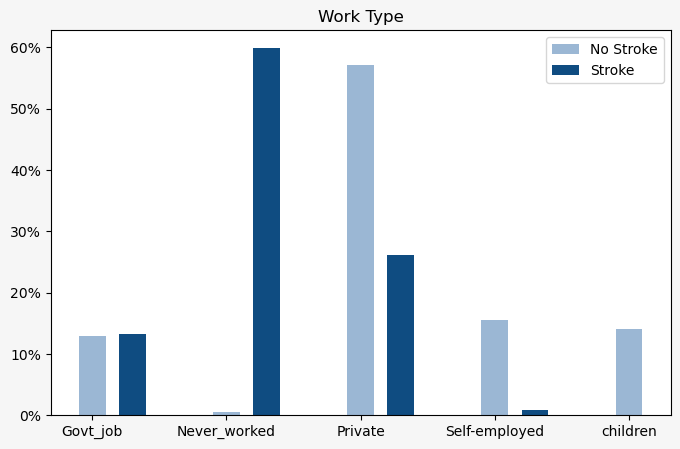

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["work_type"].value_counts()).sort_index()
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["work_type"].value_counts()).sort_index()
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

ax.bar(negative.index, negative["Percentage"], width=0.2, color="#9bb7d4", label="No Stroke")
ax.bar(np.arange(len(positive))+0.3, positive["Percentage"], width=0.2, color="#0f4c81", label="Stroke")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Work Type")
ax.legend()

plt.show()

**Hypertension**

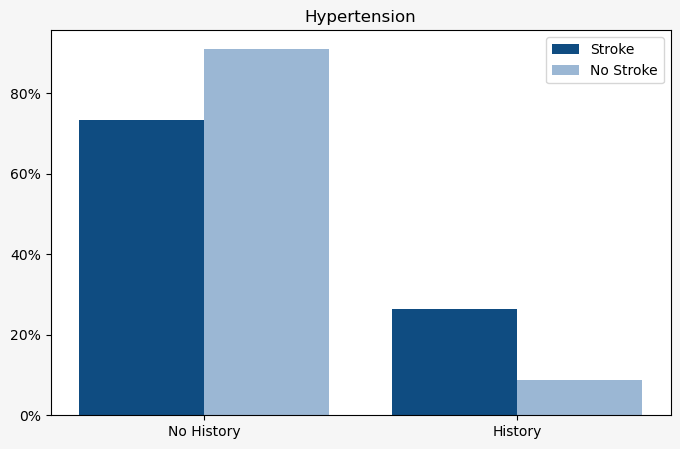

In [20]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["hypertension"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["hypertension"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Hypertension")
ax.legend()

plt.show()

**Remove ID Column**

The id column is only a patient identifier.
It does not represent a meaningful health characteristic.

In [21]:
df = df.drop('id', axis=1)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Find unique data in each column**

In [22]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')

gender : ['Male' 'Female']
ever_married : ['Yes' 'No']
work_type : ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type : ['Urban' 'Rural']
smoking_status : ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


# Label Encoding

**ever_married**

In [23]:
df['ever_married'].replace({'Yes':1,'No':0},inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_6288\50542740.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\User\AppData\Local\Temp\ipykernel_6288\50542740.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [24]:
print(f'{'ever_married'} : {df['ever_married'].unique()}')

ever_married : [1 0]


**convert into integer**

In [25]:
df.ever_married=pd.to_numeric(df.ever_married)

**gender**

In [26]:
df['gender'].replace({'Male':1,'Female':0},inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_6288\1871157913.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\User\AppData\Local\Temp\ipykernel_6288\1871157913.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [27]:
print(f'{'gender'} : {df['gender'].unique()}')

gender : [1 0]


**convert into integer**

In [28]:
df.gender=pd.to_numeric(df.gender)

# One Hot Encoding

In [29]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')

work_type : ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type : ['Urban' 'Rural']
smoking_status : ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


**now we will use one hot encoding for work type ,resisdent type and smoking status**

In [30]:
df=pd.get_dummies(data=df,columns=['work_type','Residence_type','smoking_status'])
df.sample(5)

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1017,1,79.0,0,0,1,116.67,33.5,0,False,False,False,True,False,True,False,False,False,True,False
2769,1,64.0,0,1,1,69.28,38.6,0,False,False,False,True,False,True,False,False,True,False,False
1704,1,36.0,0,0,0,233.52,40.9,0,False,False,True,False,False,True,False,False,False,True,False
3470,0,58.0,0,0,1,57.57,26.8,0,False,False,False,True,False,True,False,True,False,False,False
2695,0,50.0,0,0,1,65.98,21.7,0,False,False,True,False,False,False,True,False,False,True,False


In [31]:
df.dtypes


gender                              int64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
work_type_Govt_job                   bool
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
Residence_type_Rural                 bool
Residence_type_Urban                 bool
smoking_status_Unknown               bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

**Splitting, Imputing, and Scaling to Prevent Data Leakage**

In [32]:
# 1. Prepare features/target 
X = df.drop('stroke', axis='columns')
y = df['stroke']

# 2. Train/test split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. BMI Imputation - fit on TRAIN only, then apply to both TRAIN and TEST
bmi_imputer = BMIDecisionTreeImputer()
bmi_imputer.fit(X_train)
X_train = bmi_imputer.transform(X_train)
X_test = bmi_imputer.transform(X_test)

# 4. Scale numerical columns - fit on TRAIN only, transform both
columns_to_scale = ['age', 'avg_glucose_level', 'bmi']
scaler = MinMaxScaler()
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# Verify shapes
X_train.shape, X_test.shape

((4087, 18), (1022, 18))

**ANN(without smote)**

In [33]:
model_non_smote = keras.Sequential([
    keras.layers.Dense(32, input_shape=(X_train.shape[1],), activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_non_smote.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

non_smote = model_non_smote.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

c:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8926 - loss: 0.3559 - val_accuracy: 0.9425 - val_loss: 0.2296
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1914 - val_accuracy: 0.9425 - val_loss: 0.2211
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1809 - val_accuracy: 0.9425 - val_loss: 0.2146
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1742 - val_accuracy: 0.9425 - val_loss: 0.2071
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1685 - val_accuracy: 0.9425 - val_loss: 0.2070
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1642 - val_accuracy: 0.9425 - val_loss: 0.2023
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1610 - val_accuracy: 0.9425 - val_loss: 0.2032
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9535 - loss: 0.1584 - val_accu

In [34]:
test_loss, test_accuracy = model_non_smote.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9520547986030579


In [35]:
y_pred_probability = model_non_smote.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [36]:
y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

In [37]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Stroke', 'Stroke'],
    zero_division=0
))

              precision    recall  f1-score   support

   No Stroke       0.95      1.00      0.98       972
      Stroke       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



In [38]:
ann_accuracy = accuracy_score(y_test, y_pred)

ann_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

ann_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

ann_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

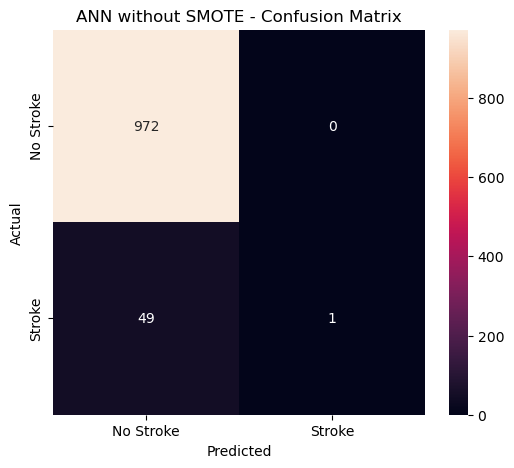

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Stroke', 'Stroke'],
    yticklabels=['No Stroke', 'Stroke']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN without SMOTE - Confusion Matrix')

plt.show()

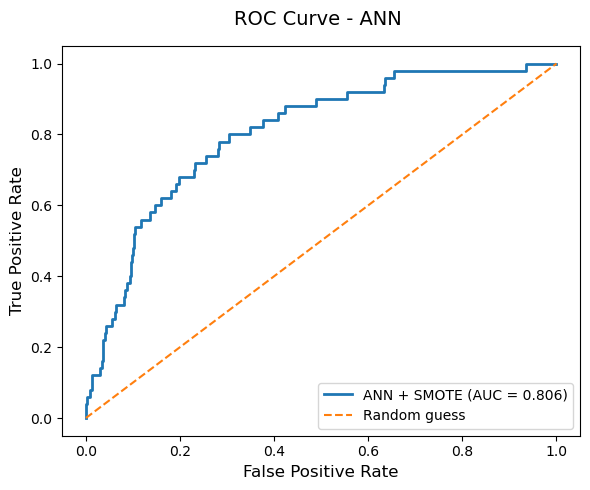

ANN ROC-AUC: 0.806


In [40]:
# Get probability predictions from ANN
y_pred_proba = model_non_smote.predict(X_test, verbose=0).ravel()

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC Curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN + SMOTE (AUC = {auc:.3f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random guess"
)

plt.title("ROC Curve - ANN ", pad=15, fontsize=14)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

print(f"ANN ROC-AUC: {auc:.3f}")

**ANN(with SMOTE)**

In [41]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
stroke
0    3888
1     199
Name: count, dtype: int64


In [42]:
smote = SMOTE(
    sampling_strategy='minority',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [43]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
stroke
0    3888
1    3888
Name: count, dtype: int64


**Find the best combination between Layer 1 number of neuron and Layer 2 number of neuron**

Split SMOTE training data into training and validation:

In [44]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_smote,
    y_train_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_train_smote
)

In [45]:
architectures = [
    (16, 8),
    (32, 16),
    (32, 8),
    (64, 32),
    (64, 16),
    (128, 64)
]

results = []

input_features = X_train_final.shape[1]

for first_layer, second_layer in architectures:

    print(f"Training: {first_layer} -> {second_layer}")

    model = keras.Sequential([
        keras.layers.Input(shape=(input_features,)),
        keras.layers.Dense(first_layer, activation='relu'),
        keras.layers.Dense(second_layer, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_final,
        y_train_final,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=0
    )

    # Validation prediction
    y_val_proba = model.predict(
        X_val,
        verbose=0
    ).ravel()

    y_val_pred = (
        y_val_proba >= 0.5
    ).astype(int)

    # Metrics
    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_val,
        y_val_proba
    )

    results.append({
        'Architecture': f'{first_layer} -> {second_layer}',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': auc
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))

Training: 16 -> 8
Training: 32 -> 16
Training: 32 -> 8
Training: 64 -> 32
Training: 64 -> 16
Training: 128 -> 64


,Architecture,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,128 -> 64,0.8837,0.8365,0.9537,0.8913,0.9465
1,64 -> 16,0.8798,0.8347,0.9473,0.8874,0.9346
2,64 -> 32,0.8766,0.8285,0.9499,0.8850,0.9312
3,32 -> 8,0.8625,0.8212,0.9267,0.8708,0.9196
4,16 -> 8,0.8560,0.8199,0.9126,0.8637,0.9141
5,32 -> 16,0.8560,0.8199,0.9126,0.8637,0.9136


display the best

In [46]:
best_architecture = results_df.iloc[0]

print("\nBEST ANN ARCHITECTURE")
print("=" * 50)

print(
    "Architecture:",
    best_architecture['Architecture']
)

print(
    "Accuracy:",
    round(best_architecture['Accuracy'], 4)
)

print(
    "Precision:",
    round(best_architecture['Precision'], 4)
)

print(
    "Recall:",
    round(best_architecture['Recall'], 4)
)

print(
    "F1 Score:",
    round(best_architecture['F1 Score'], 4)
)

print(
    "ROC-AUC:",
    round(best_architecture['ROC-AUC'], 4)
)


BEST ANN ARCHITECTURE
Architecture: 128 -> 64
Accuracy: 0.8837
Precision: 0.8365
Recall: 0.9537
F1 Score: 0.8913
ROC-AUC: 0.9465


**Final ANN**

In [47]:
model_smote = keras.Sequential([
    keras.layers.Dense(128, input_shape=(X_train_smote.shape[1],), activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_smote.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_smote = model_smote.fit(
    X_train_smote,
    y_train_smote,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


c:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7153 - loss: 0.5255 - val_accuracy: 0.7416 - val_loss: 0.5688
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8011 - loss: 0.4093 - val_accuracy: 0.7931 - val_loss: 0.5098
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8185 - loss: 0.3815 - val_accuracy: 0.7706 - val_loss: 0.5064
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8273 - loss: 0.3634 - val_accuracy: 0.8483 - val_loss: 0.4262
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8285 - loss: 0.3578 - val_accuracy: 0.8303 - val_loss: 0.4354
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8384 - loss: 0.3428 - val_accuracy: 0.7487 - val_loss: 0.5407
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8410 - loss: 0.3392 - val_accuracy: 0.7005 - val_loss: 0.6042
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8452 - loss: 0.3306 - val_accuracy: 0.7661

In [48]:
test_loss, test_accuracy = model_smote.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8091976642608643


In [49]:
y_pred_probability = model_smote.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [50]:
y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

In [51]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Stroke', 'Stroke'],
    zero_division=0
))

              precision    recall  f1-score   support

   No Stroke       0.97      0.82      0.89       972
      Stroke       0.14      0.58      0.23        50

    accuracy                           0.81      1022
   macro avg       0.56      0.70      0.56      1022
weighted avg       0.93      0.81      0.86      1022



In [52]:
ann_smote_accuracy = accuracy_score(y_test, y_pred)

ann_smote_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

ann_smote_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

ann_smote_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

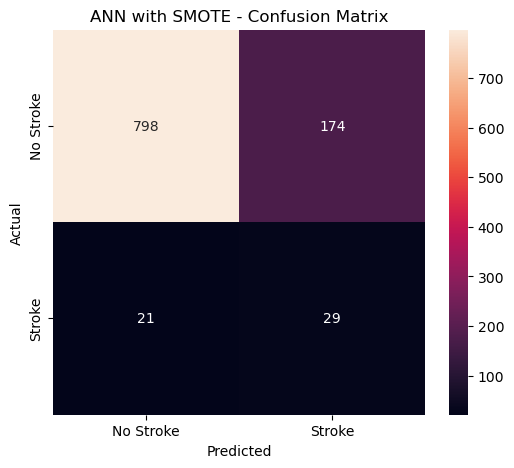

In [53]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Stroke', 'Stroke'],
    yticklabels=['No Stroke', 'Stroke']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN with SMOTE - Confusion Matrix')

plt.show()

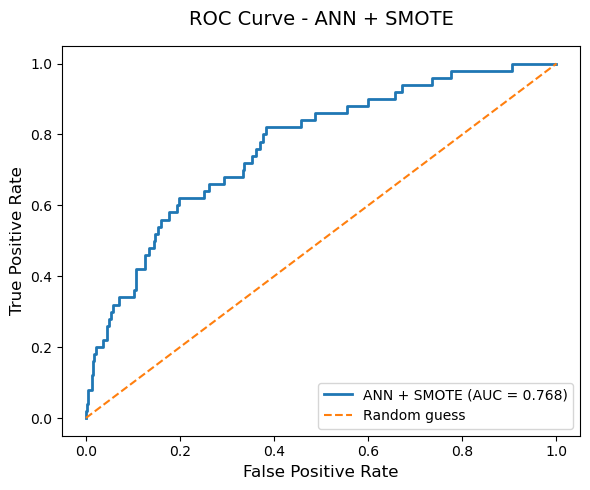

ANN + SMOTE ROC-AUC: 0.768


In [54]:
# Get probability predictions from ANN
y_pred_proba = model_smote.predict(X_test, verbose=0).ravel()

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC Curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN + SMOTE (AUC = {auc:.3f})",
    linewidth=2
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random guess"
)

plt.title("ROC Curve - ANN + SMOTE", pad=15, fontsize=14)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

print(f"ANN + SMOTE ROC-AUC: {auc:.3f}")

Feature importance

                           Feature  Importance_Mean  Importance_Std
0                              age         0.148578        0.016775
1                work_type_Private         0.056274        0.015825
2          work_type_Self-employed         0.035847        0.008857
3      smoking_status_never smoked         0.028941        0.011197
4             Residence_type_Urban         0.028888        0.007499
5               work_type_Govt_job         0.027782        0.007851
6             Residence_type_Rural         0.022193        0.010079
7               work_type_children         0.018350        0.007173
8                avg_glucose_level         0.015842        0.009772
9           smoking_status_Unknown         0.015514        0.004537
10  smoking_status_formerly smoked         0.013917        0.012001
11           smoking_status_smokes         0.013275        0.009620
12                    hypertension         0.005125        0.010752
13                    ever_married         0.005

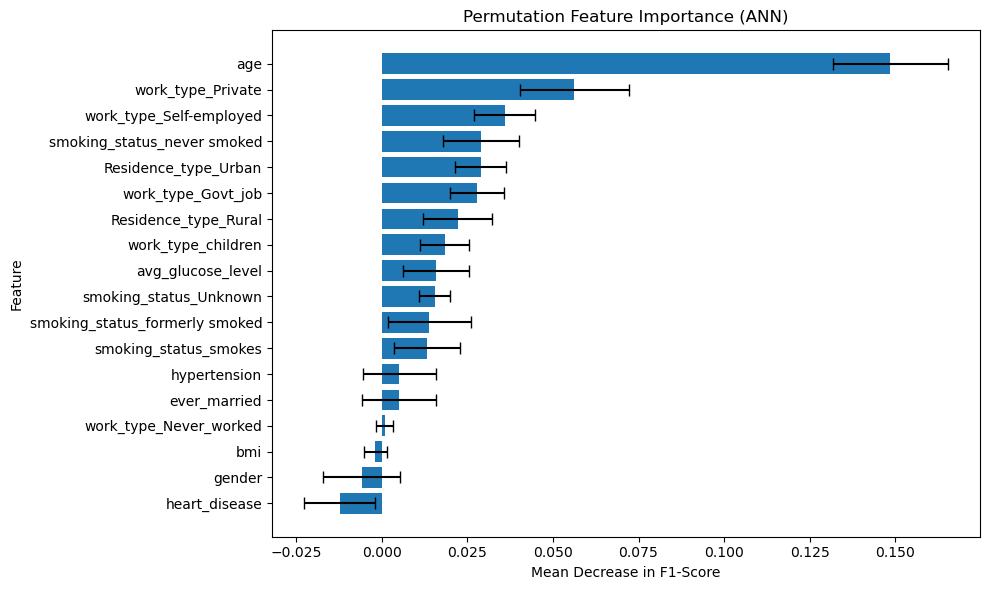

In [55]:

# ==========================================
# 1. Create F1 scorer
# ==========================================

f1_scorer = make_scorer(
    f1_score,
    zero_division=0
)


# ==========================================
# 2. Create ANN wrapper
# ==========================================

class ANNWrapper:

    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):

        # ANN gives probability
        probabilities = self.model.predict(
            X,
            verbose=0
        ).ravel()

        # Convert probability to class
        predictions = (
            probabilities >= 0.5
        ).astype(int)

        return predictions


# ==========================================
# 3. Wrap your ANN
# ==========================================

ann_wrapper = ANNWrapper(model_smote)


# ==========================================
# 4. Perform permutation importance
# ==========================================

perm_results = permutation_importance(

    ann_wrapper,

    X_test,

    y_test,

    scoring=f1_scorer,

    n_repeats=10,

    random_state=42,

    n_jobs=1
)


# ==========================================
# 5. Create results DataFrame
# ==========================================

perm_importance_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance_Mean":
        perm_results.importances_mean,

    "Importance_Std":
        perm_results.importances_std
})


# Sort from most important to least important

perm_importance_df = perm_importance_df.sort_values(

    by="Importance_Mean",

    ascending=False

).reset_index(drop=True)


print(perm_importance_df)


# ==========================================
# 6. Plot
# ==========================================

plt.figure(figsize=(10, 6))

plt.barh(

    perm_importance_df["Feature"][::-1],

    perm_importance_df["Importance_Mean"][::-1],

    xerr=perm_importance_df["Importance_Std"][::-1],

    capsize=4
)

plt.xlabel("Mean Decrease in F1-Score")

plt.ylabel("Feature")

plt.title(
    "Permutation Feature Importance (ANN)"
)

plt.tight_layout()

plt.show()

In [56]:
comparison = pd.DataFrame({
    'Model': ['ANN', 'ANN + SMOTE'],
    'Accuracy': [ann_accuracy, ann_smote_accuracy],
    'Precision': [ann_precision, ann_smote_precision],
    'Recall': [ann_recall, ann_smote_recall],
    'F1': [ann_f1, ann_smote_f1]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1
0,ANN,0.9521,1.0000,0.02,0.0392
1,ANN + SMOTE,0.8092,0.1429,0.58,0.2292


In [57]:
import joblib


# Save trained Keras ANN model
model_smote.save("stroke_ann_smote.keras")

# Save the MinMaxScaler
joblib.dump(
    scaler,
    "ann_scaler.pkl"
)

# BMI imputation (fit on X_train only) before scaling/predicting on new raw input.
joblib.dump(
    bmi_imputer,
    "ann_bmi_imputer.pkl"
)

# Save the exact feature columns and order
joblib.dump(
    list(X_train.columns),
    "ann_columns.pkl"
)

print("========================================")
print("ANN model saved successfully!")
print("========================================")
print("stroke_ann_smote.keras")
print("ann_scaler.pkl")
print("ann_bmi_imputer.pkl")
print("ann_columns.pkl")

ANN model saved successfully!
stroke_ann_smote.keras
ann_scaler.pkl
ann_bmi_imputer.pkl
ann_columns.pkl
